In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_excel("../data/co2 solubility dataset.xlsx",sheet_name=4)

In [4]:
df.head()

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
0,[Bmim][PF6],1-butyl-3-methyl-imidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,25.0,83.0,0.75
1,[Emim][Tf2N],1-ethyl-3-methylimidazolium,bis(trifluoromethylsulfonyl)imide,CC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.17
2,[Bmim][Tf2N],1-butyl-3-methyl-imidazolium,bis(trifluoromethylsulfonyl)imide,CCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.18
3,[Omim][Tf2N],1-octyl-3-methyl-imidazolium,bis(trifluoromethylsulfonyl)imide,CCCCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.19
4,[C12mim][Tf2N],1-dodecyl-3-methyl-imidazolium,bis(trifluoromethylsulfonyl)imide,CCCCCCCCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.21


In [5]:
df.sample(5)

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
4885,[Emim][NTf₂],1-ethyl-3-methylimidazolium,bis((trifluoromethyl)sulfonyl)imide,CC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,64.85,4.990,0.058201
2281,[BMIM][Gly],1-butyl-3-methylimidazolium,glycinate,CCCC[n+]1ccn(C)c1,C(C(=O)[O-])N,35.00,0.595,0.503767
2441,[Emim][FAP],1-ethyl-3-methylimidazolium,tris(pentafluoroethyl)trifluorophosphate,CC[n+]1ccn(C)c1,F[P-](F)(F)(C(F)(F)C(F)(F)F)(C(F)(F)C(F)(F)F)(...,60.00,18.328,0.452174
46,[MTBDH][Im],"methyl-1,5,7-triazabicyclo[4.4.]dec-5-ene",Imidazolate,C[NH+]1CCNC2=NCCCN12,C1=CN=C[N-]1,23.00,1.000,1.030000
4313,[OMIM][BF4],1-methyl-3-octylimidazolium,tetrafluoroborate,CCCCCCCC[n+]1ccn(C)c1,F[B-](F)(F)F,50.00,5.310,0.097695


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   IL NAME                        5462 non-null   str    
 1   CATION NAME                    5462 non-null   str    
 2   ANION NAME                     5462 non-null   str    
 3   Cation_SMILES                  5462 non-null   str    
 4   Anion_SMILES                   5462 non-null   str    
 5   Temperature (0 C)              5462 non-null   float64
 6   Pressure (bar)                 5462 non-null   float64
 7   CO2 capacity (mol CO2/mol IL)  5462 non-null   float64
dtypes: float64(3), str(5)
memory usage: 341.5 KB


In [7]:
df.describe()
#to see statistical description of the raw data

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
count,5462.000000,5462.000000,5462.000000
mean,43.052819,16.705380,2.181734
std,21.032388,28.280796,135.291052
min,4.970000,0.000013,0.000000
25%,25.000000,2.000000,0.072612
50%,40.000000,8.500000,0.188106
75%,59.980000,16.999000,0.414427
max,139.950000,345.500000,9999.000000


In [8]:
df.isnull().sum()
#to see if any column has any null or missing value==> which comes out to be zero

IL NAME                          0
CATION NAME                      0
ANION NAME                       0
Cation_SMILES                    0
Anion_SMILES                     0
Temperature (0 C)                0
Pressure (bar)                   0
CO2 capacity (mol CO2/mol IL)    0
dtype: int64

In [9]:
print(df.duplicated(subset=df.columns,keep=False).sum())
#checking if rows are exactly duplicate having all values same==> which came out to be around 222

222


In [10]:
df[df.duplicated(subset=df.columns,keep=False)]

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
79,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,6.0,0.161440
80,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,6.0,0.161440
85,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,7.5,0.201923
86,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,7.5,0.201923
91,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,9.0,0.243781
...,...,...,...,...,...,...,...,...
4768,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.25,1.0,0.030928
4777,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.25,14.8,0.540832
4778,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.25,14.8,0.540832
5184,[P1444i][OTs],triisobutylmethylphosphonium,p-toluenesulfonate,CC(C)C[P+](C)(CC(C)C)CC(C)C,CC1=CC=C(C=C1)S(=O)(=O)[O-],50.00,13.0,0.137656


In [11]:
df1=df.drop_duplicates(subset=df.columns)
#removing the duplicate rows from the dataset

In [12]:
df1.describe()

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
count,5350.000000,5350.000000,5350.000000
mean,43.358114,16.818637,2.220903
std,21.041523,28.555921,136.699833
min,4.970000,0.000013,0.000000
25%,25.000000,2.000000,0.070692
50%,40.000000,8.451000,0.186120
75%,59.980000,17.110500,0.412429
max,139.950000,345.500000,9999.000000


In [13]:
print(df1.duplicated(subset=df.columns,keep=False).sum())
#doing a sanity check to see if there are still any duplicate rows there==> no duplicates present

0


In [14]:
df.columns

Index(['IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES', 'Anion_SMILES',
       'Temperature (0 C)', 'Pressure (bar)', 'CO2 capacity (mol CO2/mol IL)'],
      dtype='str')

In [37]:
df["CATION NAME"].nunique()
# this doesnt represent that there are 77 unique columns as the spelling might be a little different there may be a '-' in the same spelling

77

In [42]:
unique_cations = df["CATION NAME"].unique().tolist()

print(unique_cations)

['1-butyl-3-methyl-imidazolium', '1-ethyl-3-methylimidazolium', '1-octyl-3-methyl-imidazolium', '1-dodecyl-3-methyl-imidazolium', '1-aminobytyl-3-imidazolium', '3-aminemethyl-1-n-butyl imidazolium', '1-aminopropyl-3-imidazolium', '1,3-di(2′-aminoethyl)-2-methylimidazolium', 'triethylenetetrammonium', 'trihexyl(tetradecyl)phosphonium', 'trihexyl(tetradecyl)ammonium', '3-aminopropyl)tributylphosphonium', '1,1,1-trimethylhydrazinium', '1-aminoethyl-3-methylimidazolium', 'diethylenetriammonium', 'N, N-dimethyl-1,3-propane diamine', 'methyl-1,5,7-triazabicyclo[4.4.]dec-5-ene', 'triethyl(octyl)phosphonium', 'Diethyelenetriammonium ', '1-butyl-3-methylimidazolium', '1-butyl-2,3-dimethylimidazolium', ' 1-methyl-3-octylimidazolium', '1-heptyl-3-methylimidazolium', '3-hexyl-1-methylimidazolium', '1-ethyl-3-methyl-1H-imidazolium', '1-methyl-1-propylpyrrolidinium', '1-hexyl-3-methylimidazolium', '1-butyl-1-methylpyrrolidinium', '1-hexyl-1-methylpyrrolidinium', '1-hexyl-3-methylpyridinium', ' 1-but

In [ ]:
df_anions = pd.DataFrame(unique_cations, columns=["Anion"])

df_anions.to_excel("../outputs/tables/unique_cations.xlsx", index=False)

: 

In [16]:
df["CATION NAME"].value_counts()

CATION NAME
1-butyl-3-methylimidazolium          1042
1-hexyl-3-methylimidazolium           516
1-ethyl-3-methylimidazolium           468
1-butyl-2,3-dimethylimidazolium       226
1-butyl-1-methylpyrrolidinium         189
                                     ... 
3-aminopropyl)tributylphosphonium       1
1,1,1-trimethylhydrazinium              1
1-aminoethyl-3-methylimidazolium        1
diethylenetriammonium                   1
N, N-dimethyl-1,3-propane diamine       1
Name: count, Length: 77, dtype: int64

In [17]:
df["ANION NAME"].nunique()
## this doesnt represent that there are 77 unique columns as the spelling might be a little different there may be a '-' in the same spelling
## or for the same anion there might be common name at some places and iupac at others



80

In [41]:
unique_anions = df["ANION NAME"].unique().tolist()

print(unique_anions)

['hexafluorophosphate', 'bis(trifluoromethylsulfonyl)imide', 'nitrate', 'dicyanamide', 'tetrafluoroborate', 'trifluooromethanesulfonate', 'Methide', ' bromide', 'piperazine', 'imidazolate', 'pyrazolate', '1,2,4-triazolate', 'prolinate', 'methioninate', 'glycinate', 'L-α-aminopropionic acid', 'sarcosinate', 'isoleucinate', 'lysinate', 'histidine', 'asparaginate', 'glutamate', 'Alanate', 'phenolate', 'p-methylphenolate', 'p-chlorophenolate', 'p-trifluoromethylphenolate', 'p-nitrophenolate', 'p-fluorophenolate', 'cinnamate', '2-methoxyl cinnamate', '4-trifluoromethyl cinnamate', 'trifluoroethyl', 'Imidazolate', '2-cyanopyrrol-1-ide', '3-(trifluoromethyl)pyrazol-1-ide', '3-methyl-5-(trifluoromethyl)pyrazol-1-ide', '4-nitropyrazol-1-ide', 'Formate', 'Butanoate', 'Hexanoate', 'Octanoate', 'tricyanomethane', 'tricyanomethanide', 'ethyl sulfate', 'bis((trifluoromethyl)sulfonyl)imide', 'bis[(trifluoromethyl)sulfonyl]imide', 'bis(trifluoromethanesulfonyl)imide', 'methyl sulfate', 'acetate', '1,1

In [43]:
df_anions = pd.DataFrame(unique_anions, columns=["Anion"])

df_anions.to_excel("../outputs/tables/unique_anions.xlsx", index=False)

In [18]:
df["ANION NAME"].value_counts()

ANION NAME
bis[(trifluoromethyl)sulfonyl]imide    745
hexafluorophosphate                    524
tetrafluoroborate                      482
bis(trifluoromethylsulfonyl)imide      409
tricyanomethanide                      404
                                      ... 
4-nitropyrazol-1-ide                     1
Formate                                  1
Butanoate                                1
Hexanoate                                1
Octanoate                                1
Name: count, Length: 80, dtype: int64

In [19]:
df["CATION NAME"].nunique("IL NAME")

77

<Axes: xlabel='Temperature (0 C)'>

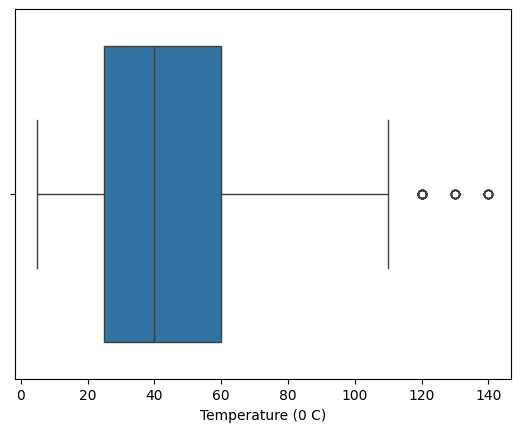

In [20]:
sns.boxplot(x=df["Temperature (0 C)"])
#box-plot is used to see the statistical distribution of the data.
#the left most line represents min value in the column
#the subsequent 3 lines of blue box represent 25 percentile 50 percentile and 75 percentile values
# the last line represnt the max value to be not called an outlier
# the min and max are calculated using inter quartile range

<Axes: xlabel='Pressure (bar)'>

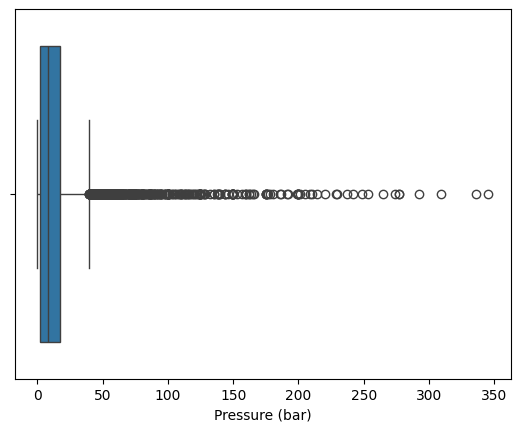

In [21]:
sns.boxplot(x=df1["Pressure (bar)"])

<Axes: xlabel='Pressure (bar)', ylabel='Count'>

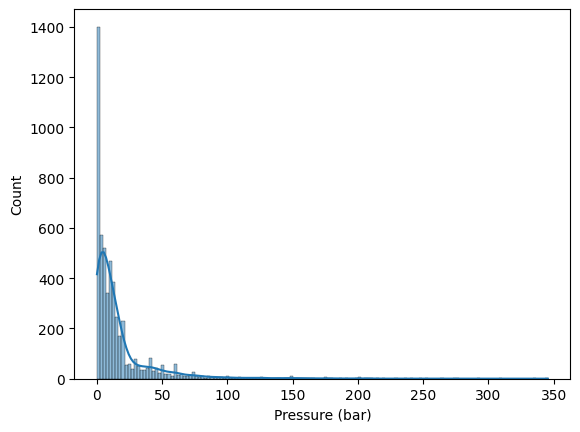

In [22]:
sns.histplot(data=df1["Pressure (bar)"],kde=True)
#this is a distribution plot showing that the data is right skewed

In [23]:
df.columns

Index(['IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES', 'Anion_SMILES',
       'Temperature (0 C)', 'Pressure (bar)', 'CO2 capacity (mol CO2/mol IL)'],
      dtype='str')

In [24]:
corr=df1[["Temperature (0 C)","Pressure (bar)","CO2 capacity (mol CO2/mol IL)"]].corr()
corr
# this is to check correlation between the colums
# this shows that presure is positively correlated with co2 solubility
# this also shows that temperature is negatively corellated with co2 solubility

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
Temperature (0 C),1.000000,0.361406,-0.012089
Pressure (bar),0.361406,1.000000,0.024703
CO2 capacity (mol CO2/mol IL),-0.012089,0.024703,1.000000


<Axes: >

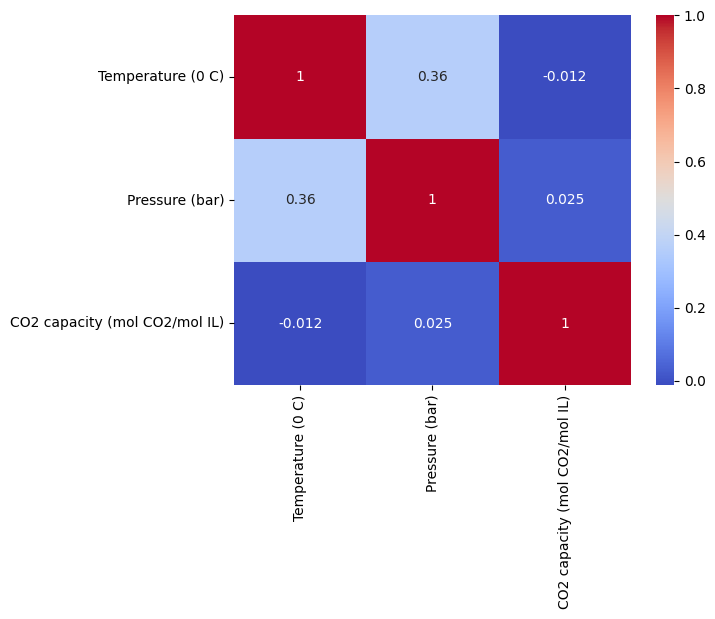

In [25]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
#this plot is just representation of the correlation data

<Axes: xlabel='CO2 capacity (mol CO2/mol IL)'>

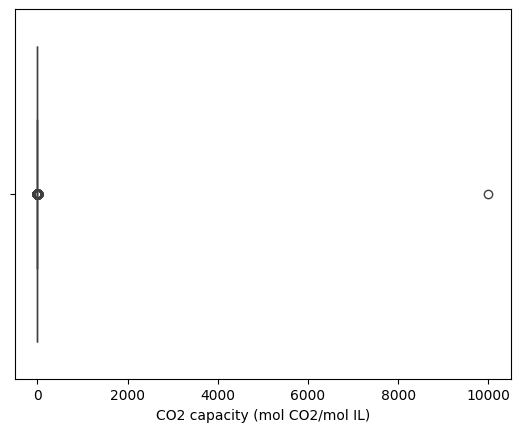

In [26]:
sns.boxplot(x=df1["CO2 capacity (mol CO2/mol IL)"])
#one odd outlier data is present which is almost equal to 10000 where most values are around 0 to 10 range which is strange

In [27]:
df1[df1["CO2 capacity (mol CO2/mol IL)"]>100]
#checking which column is the one having that outlier

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
4720,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.96,64.2,9999.0


In [28]:
df1["CO2 capacity (mol CO2/mol IL)"].sort_values().tail()

1561       6.692308
5130       7.032129
5122       7.431703
5123       8.293680
4720    9999.000000
Name: CO2 capacity (mol CO2/mol IL), dtype: float64

In [29]:
df1=df1[df1["CO2 capacity (mol CO2/mol IL)"]<100]
#removing the row that contains the outlier

<Axes: xlabel='CO2 capacity (mol CO2/mol IL)'>

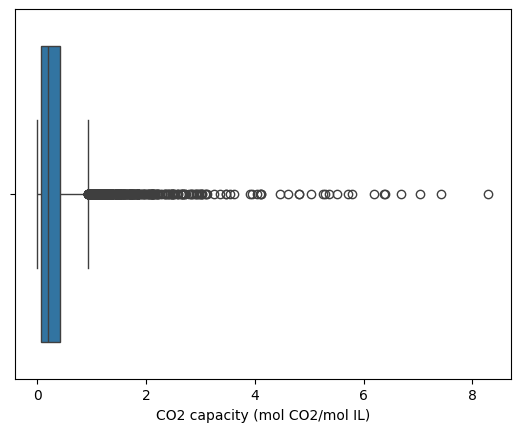

In [30]:
sns.boxplot(x=df1["CO2 capacity (mol CO2/mol IL)"])
#now the distribution looks uniform

In [31]:
df1.columns

Index(['IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES', 'Anion_SMILES',
       'Temperature (0 C)', 'Pressure (bar)', 'CO2 capacity (mol CO2/mol IL)'],
      dtype='str')

Text(0, 0.5, 'CO2 capacity (mol CO2/mol IL)')

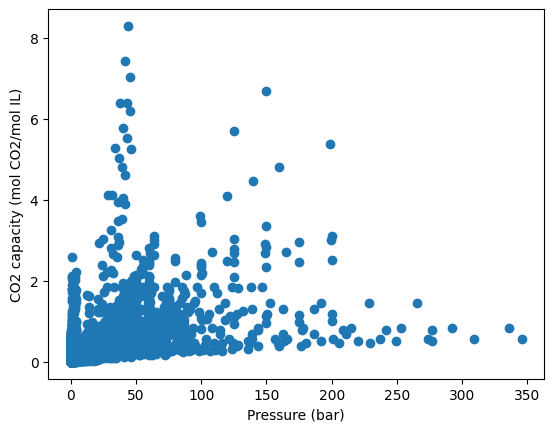

In [32]:
plt.Figure(figsize=(20,20))
plt.scatter(x=df1["Pressure (bar)"],y=df1["CO2 capacity (mol CO2/mol IL)"])
plt.xlabel("Pressure (bar)")
plt.ylabel("CO2 capacity (mol CO2/mol IL)")
# this scatter plot shows that the distribution of pressure and co2 solubility is not linear at all

<Axes: xlabel='Pressure (bar)', ylabel='CO2 capacity (mol CO2/mol IL)'>

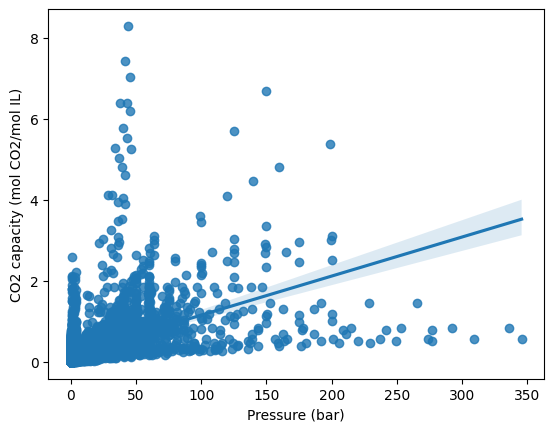

In [33]:
sns.regplot(x=df1["Pressure (bar)"],y=df1["CO2 capacity (mol CO2/mol IL)"])
#this plot shows that the best fit line is unable to capture the relationship 

Text(0, 0.5, 'CO2 capacity (mol CO2/mol IL)')

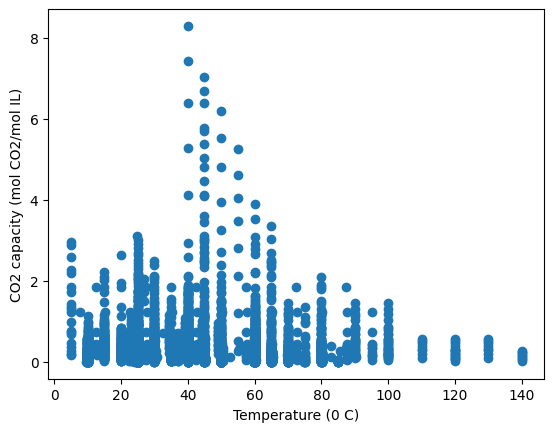

In [34]:
plt.scatter(x=df1["Temperature (0 C)"],y=df1["CO2 capacity (mol CO2/mol IL)"])
plt.xlabel("Temperature (0 C)")
plt.ylabel("CO2 capacity (mol CO2/mol IL)")

In [35]:
df1.describe()

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
count,5349.000000,5349.000000,5349.000000
mean,43.361554,16.809779,0.351997
std,21.041986,28.551239,0.556316
min,4.970000,0.000013,0.000000
25%,25.000000,2.000000,0.070664
50%,40.000000,8.442000,0.186000
75%,59.980000,17.100000,0.412429
max,139.950000,345.500000,8.293680


In [36]:
df1.to_csv( "../data/co2_solubility_cleaned.csv",index=False)